# Final Model Big

## Set up

In [1]:
import sys

COLAB = "google.colab" in sys.modules

# Environment Setup
if COLAB:
    print("Running in Google Colab. Setting up environment...")
    BASE_DIR = './'  # In Colab, everything stays inside /content/

    import gdown
    requirements_ID = '1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN'
    gdown.download(id=requirements_ID, output='requirements.txt', quiet=False)
    %pip install -r "requirements.txt"
else:
    print("Running locally. Assuming files are already present.")
    BASE_DIR = '../' # Locally, everything is one level up from /src

    requirements_path = f"{BASE_DIR}requirements.txt"
    %pip install -r "{requirements_path}"

Running in Google Colab. Setting up environment...


Downloading...
From: https://drive.google.com/uc?id=1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN
To: /content/requirements.txt
100%|██████████| 164/164 [00:00<00:00, 609kB/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 6.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.1/179.1 kB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 98.4 MB/s eta 0:00:00:00

In [2]:
import os
import tensorflow as tf
import tf_keras as keras
import numpy as np
from sklearn.model_selection import train_test_split
import optuna
from tf_keras.models import Sequential
from tf_keras.layers import Conv2D, Flatten, Dense, ReLU, Input, Dropout
from tf_keras.optimizers import Adam
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tf_keras.losses import SparseCategoricalCrossentropy
from quantizeml import load_model
from quantizeml.models import quantize, QuantizationParams
from quantizeml.models.quantize import dump_config
from cnn2snn import set_akida_version, AkidaVersion, convert
import cnn2snn
import akida
import json
import datetime
import matplotlib.pyplot as plt

In [3]:
# Force TensorFlow to use the legacy Keras 2 backend
# This is strictly required because Brainchip's cnn2snn converter crashes with Keras 3
os.environ["TF_USE_LEGACY_KERAS"] = "1"

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras module: {keras.__name__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.1
Keras module: tf_keras
Keras version: 2.19.0


## Dataset download and load

In [4]:
# Dataset download
dataset_dir = os.path.join(BASE_DIR, 'data/processed_data/')
dataset_path = os.path.join(dataset_dir, 'X_watch_20Hz_scaled_big.npy')
labels_path = os.path.join(dataset_dir, 'y_watch_labels_big.npy')

if not os.path.exists(dataset_path) or not os.path.exists(labels_path):
    dataset_ID = '1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC'
    labels_ID = '1QK7vxsYoPedcbsWKziA4NOp9x4SMVqH4'

    print(f"Dataset or labels not found in {dataset_dir}. Downloading...")
    os.makedirs(dataset_dir, exist_ok=True)
        
    gdown.download(id=dataset_ID, output=dataset_path, quiet=False)
    gdown.download(id=labels_ID, output=labels_path, quiet=False)
    print("Download complete!")
else:
    print(f"Dataset and labels already exist in {dataset_dir}. Skipping download.")

Dataset or labels not found in ./data/processed_data/. Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC
From (redirected): https://drive.google.com/uc?id=1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC&confirm=t&uuid=5e682778-cb3f-4c9b-a14e-c275ce238676
To: /content/data/processed_data/X_watch_20Hz_scaled_big.npy
100%|██████████| 161M/161M [00:02<00:00, 61.5MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1QK7vxsYoPedcbsWKziA4NOp9x4SMVqH4
To: /content/data/processed_data/y_watch_labels_big.npy
100%|██████████| 1.34M/1.34M [00:00<00:00, 140MB/s]

Download complete!


In [5]:
# Dataset load
try:
    X_data = np.load(dataset_path)
    y_labels = np.load(labels_path).astype(np.int32)

    print(f"Dataset loaded successfully from: {dataset_path}")
    print(f"Labels loaded successfully from: {labels_path}")

    print(f"\nX_data shape: {X_data.shape}")
    print(f"y_labels shape: {y_labels.shape}, dtype: {y_labels.dtype}")

except FileNotFoundError:
    print(f"Error: One or both files were not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully from: ./data/processed_data/X_watch_20Hz_scaled_big.npy
Labels loaded successfully from: ./data/processed_data/y_watch_labels_big.npy

X_data shape: (167247, 40, 6)
y_labels shape: (167247,), dtype: int32


### Dataset Split

In [6]:
def split_and_save_dataset(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=random_state, stratify=y
    )

    relative_val_size = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = split_and_save_dataset(X_data, y_labels, train_size=0.7, val_size=0.15, test_size=0.15)

# Remap the labels into a continuous range [0, N-1]
unique_labels = np.unique(y_train)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

def apply_mapping(labels, mapping):
    return np.array([mapping[label] for label in labels], dtype=np.int32)

y_train = apply_mapping(y_train, label_mapping)
y_val = apply_mapping(y_val, label_mapping)
y_test = apply_mapping(y_test, label_mapping)

num_classes = len(unique_labels)

print(f"Number of unique classes detected: {num_classes}")
print(f"Applied mapping: {label_mapping}")
print(f"X_train dimensions: {X_train.shape}, y_train: {y_train.shape}")

Number of unique classes detected: 18
Applied mapping: {np.int32(0): 0, np.int32(1): 1, np.int32(2): 2, np.int32(3): 3, np.int32(4): 4, np.int32(5): 5, np.int32(6): 6, np.int32(7): 7, np.int32(8): 8, np.int32(9): 9, np.int32(10): 10, np.int32(11): 11, np.int32(12): 12, np.int32(13): 13, np.int32(14): 14, np.int32(15): 15, np.int32(16): 16, np.int32(17): 17}
X_train dimensions: (117072, 40, 6), y_train: (117072,)


In [8]:
X_train_reshaped = X_train.reshape(-1, 40, 6, 1)
X_val_reshaped = X_val.reshape(-1, 40, 6, 1)
X_test_reshaped = X_test.reshape(-1, 40, 6, 1)

# 41x9 for hardware symmetric padding
pad_config = ((0,0), (0,1), (1,2), (0,0))
X_train_padded = np.pad(X_train_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_val_padded = np.pad(X_val_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_test_padded = np.pad(X_test_reshaped, pad_width=pad_config, mode='constant', constant_values=0)

x_min = np.min(X_train_padded)
x_max = np.max(X_train_padded)

# Range [0.0, 1.0] in float32 (for input_quantizer)
X_train = ((X_train_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_val = ((X_val_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_test = ((X_test_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)

## Model (Big)
Model trained on all dataset

In [9]:
# Dictionaries for fixed parameters
hardware_settings = {
    "input_shape": (41, 9, 1),
    "num_classes": num_classes,
    "max_relu": 6,
    "qparams": QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4)
}

training_settings = {
    "epochs": 10,
    "patience": 5
}

fixed_settings = dict(hardware_settings, **training_settings)

## Optuna

In [10]:
def create_dynamic_model(trial, settings):
    """Builds the Keras model based on the parameters suggested by Optuna."""

    # Hyperparameters chosen by Optuna
    conv1_filters = trial.suggest_categorical('conv1_filters', [32, 48, 64])
    conv2_filters = trial.suggest_categorical('conv2_filters', [64, 96, 128])
    conv3_filters = trial.suggest_categorical('conv3_filters', [128, 192, 256])
    conv4_filters = trial.suggest_categorical('conv4_filters', [16, 24, 32, 48, 64])

    # Optuna decides whether to use 1 or 2 final Dense layers
    num_dense_layers = trial.suggest_int('num_dense_layers', 1, 2)
    dense1_units = trial.suggest_int('dense1_units', 32, 128, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5, step=0.1)

    model = Sequential([
        Input(shape=settings["input_shape"]),

        Conv2D(filters=conv1_filters, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=settings["max_relu"]),

        Conv2D(filters=conv2_filters, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=settings["max_relu"]),

        Conv2D(filters=conv3_filters, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=settings["max_relu"]),

        Conv2D(filters=conv4_filters, kernel_size=(1, 1), strides=(1, 1), padding='same'),
        ReLU(max_value=settings["max_relu"]),

        Flatten()
    ])

    # Dynamic addition of Dense layers
    model.add(Dense(dense1_units))
    model.add(ReLU(max_value=settings["max_relu"]))
    model.add(Dropout(dropout_rate))

    if num_dense_layers == 2:
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=16)
        model.add(Dense(dense2_units))
        model.add(ReLU(max_value=settings["max_relu"]))
        model.add(Dropout(dropout_rate))

    model.add(Dense(settings["num_classes"]))

    return model

In [11]:
def objective(trial):
    print(f"\n--- Starting Trial {trial.number} ---")

    # Model creation
    model = create_dynamic_model(trial, fixed_settings)

    # Hardware Check (Preventive Pruning)
    # We use a subset of the training set for a dummy, ultra-fast calibration
    dummy_calibration = X_train[:1024]

    try:
        # Dummy quantization
        with set_akida_version(AkidaVersion.v1):
            q_model_dummy = quantize(model, qparams=fixed_settings["qparams"], samples=dummy_calibration)
            akida_model_dummy = cnn2snn.convert(q_model_dummy)

            # Mapping on AKD1000 to read memory usage
            device = akida.AKD1000()
            akida_model_dummy.map(device=device)

            ext_memory = akida_model_dummy.external_memory_size

            if ext_memory > 0:
                # The network is too large, we interrupt this trial immediately
                raise optuna.TrialPruned(f"Pruned: Requires {ext_memory} bytes of external memory.")

    except Exception as e:
        # If the conversion fails due to structural incompatibilities, we discard the trial
        if isinstance(e, optuna.TrialPruned):
            raise e
        raise optuna.TrialPruned(f"Pruned due to conversion error: {str(e)}")

    # Training (Only for models that pass the hardware test)
    lr = trial.suggest_float('learning_rate', 3e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=fixed_settings["patience"],
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=fixed_settings["epochs"],
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    # Return the best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    print(f"--- Trial {trial.number} finished with accuracy: {best_val_acc} ---")

    return best_val_acc

In [12]:
# Running the study
print("Starting Optuna optimization...")
study = optuna.create_study(direction='maximize')
# Set n_trials based on the time you have available (e.g., 30-50 to start)
study.optimize(objective, n_trials=5)

print("\n--- Best Hyperparameters Found ---")
print(study.best_params)
print(f"Best Val Accuracy (Baseline Keras): {study.best_value * 100:.2f}%")

[I 2026-07-01 10:35:22,239] A new study created in memory with name: no-name-e0b211b3-841c-474c-948a-f983a3544ff2


Starting Optuna optimization...

--- Starting Trial 0 ---
1024/1024 [==============================] - 4s 3ms/step


[I 2026-07-01 10:35:45,122] Trial 0 pruned. Pruned: Requires 11392 bytes of external memory.



--- Starting Trial 1 ---
1024/1024 [==============================] - 4s 3ms/step


[I 2026-07-01 10:36:00,549] Trial 1 pruned. Pruned: Requires 44592 bytes of external memory.


...

--- Trial 2 finished with accuracy: 0.6422848701477051 ---

--- Starting Trial 3 ---
1024/1024 [==============================] - 3s 3ms/step


[I 2026-07-01 10:38:03,172] Trial 3 pruned. Pruned: Requires 56832 bytes of external memory.



--- Starting Trial 4 ---
1024/1024 [==============================] - 4s 4ms/step


[I 2026-07-01 10:38:18,105] Trial 4 pruned. Pruned: Requires 5840 bytes of external memory.



--- Best Hyperparameters Found ---
{'conv1_filters': 48, 'conv2_filters': 96, 'conv3_filters': 192, 'conv4_filters': 32, 'num_dense_layers': 1, 'dense1_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0006295899970202857, 'batch_size': 64}
Best Val Accuracy (Baseline Keras): 64.23%


In [13]:
best_params = study.best_params

In [14]:
# Define the path in your existing Google Drive directory
drive_models_dir = os.path.join(BASE_DIR, 'models/big/best_params')
os.makedirs(drive_models_dir, exist_ok=True) # Ensures the folder exists
params_file_path = os.path.join(drive_models_dir, 'best_optuna_params_big.json')

# Save the dictionary to a JSON file
with open(params_file_path, 'w') as json_file:
    json.dump(best_params, json_file, indent=4)

print(f"Success! Best parameters securely saved to:\n{params_file_path}")

Success! Best parameters securely saved to:
./models/big/best_params/best_optuna_params_big.json


### Load param

In [16]:
params_file_path = os.path.join(BASE_DIR, 'models/big/best_params/best_optuna_params_big.json')

# Load the file back into a Python dictionary
with open(params_file_path, 'r') as json_file:
    loaded_params = json.load(json_file)

print("Loaded parameters from Drive:")
print(loaded_params)

Loaded parameters from Drive:
{'conv1_filters': 48, 'conv2_filters': 96, 'conv3_filters': 192, 'conv4_filters': 32, 'num_dense_layers': 1, 'dense1_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0006295899970202857, 'batch_size': 64}


In [17]:
def create_akida_compatible_baseline(num_classes):
    l2_factor = 1e-4

    optimized_model = Sequential([
        Input(shape=fixed_settings["input_shape"]),

        Conv2D(filters=loaded_params['conv1_filters'], kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=fixed_settings["max_relu"]),

        Conv2D(filters=loaded_params['conv2_filters'], kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=fixed_settings["max_relu"]),

        Conv2D(filters=loaded_params['conv3_filters'], kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=fixed_settings["max_relu"]),

        Conv2D(filters=loaded_params['conv4_filters'], kernel_size=(1, 1), strides=(1, 1), padding='same'),
        ReLU(max_value=fixed_settings["max_relu"]),

        Flatten(),

        Dense(loaded_params['dense1_units']),
        ReLU(max_value=fixed_settings["max_relu"]),
        Dropout(loaded_params['dropout_rate']),
    ])

    if loaded_params.get('num_dense_layers', 1) == 2:
        optimized_model.add(Dense(loaded_params['dense2_units']))
        optimized_model.add(ReLU(max_value=fixed_settings["max_relu"]))
        optimized_model.add(Dropout(loaded_params['dropout_rate']))

    optimized_model.add(Dense(fixed_settings["num_classes"]))

    return optimized_model

optimized_model = create_akida_compatible_baseline(num_classes)
LR = loaded_params['learning_rate']

optimized_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

optimized_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 21, 5, 48)         480       
                                                                 
 re_lu_31 (ReLU)             (None, 21, 5, 48)         0         
                                                                 
 conv2d_21 (Conv2D)          (None, 11, 3, 96)         41568     
                                                                 
 re_lu_32 (ReLU)             (None, 11, 3, 96)         0         
                                                                 
 conv2d_22 (Conv2D)          (None, 6, 2, 192)         166080    
                                                                 
 re_lu_33 (ReLU)             (None, 6, 2, 192)         0         
                                                                 
 conv2d_23 (Conv2D)          (None, 6, 2, 32)         

## Training Loop

In [18]:
# Create the directory to save models if it does not exist
models_dir = os.path.join(BASE_DIR, 'models/big')
checkpoints_dir = os.path.join(models_dir, 'checkpoint')
os.makedirs(checkpoints_dir, exist_ok=True)

model_path = os.path.join(checkpoints_dir, 'final_model_big_optuna.h5')

# TensorBoard log
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Definition of Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    verbose=1,
    min_lr=1e-7
)

# Training (Training Loop)
EPOCHS = 30
BATCH_SIZE = loaded_params['batch_size']

In [19]:
print("Starting training...")
history = optimized_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint, lr_scheduler, tensorboard_callback],
    verbose=1
)

Starting training...
Epoch 1/30
1828/1830 [============================>.] - ETA: 0s - loss: 2.2377 - accuracy: 0.2458
Epoch 1: val_loss improved from inf to 1.71579, saving model to ./models/big/checkpoint/final_model_big_optuna.h5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1830/1830 [==============================] - 14s 6ms/step - loss: 2.2375 - accuracy: 0.2459 - val_loss: 1.7158 - val_accuracy: 0.4359 - lr: 6.2959e-04
Epoch 2/30
1824/1830 [============================>.] - ETA: 0s - loss: 1.6336 - accuracy: 0.4562
Epoch 2: val_loss improved from 1.71579 to 1.40847, saving model to ./models/big/checkpoint/final_model_big_optuna.h5
1830/1830 [==============================] - 11s 6ms/step - loss: 1.6328 - accuracy: 0.4565 - val_loss: 1.4085 - val_accuracy: 0.5298 - lr: 6.2959e-04
Epoch 3/30
1824/1830 [============================>.] - ETA: 0s - loss: 1.4522 - accuracy: 0.5149
Epoch 3: val_loss improved from 1.40847 to 1.32272, saving model to ./models/big/checkpoint/final_model_big_optuna.h5
1830/1830 [==============================] - 11s 6ms/step - loss: 1.4520 - accuracy: 0.5150 - val_loss: 1.3227 - val_accuracy: 0.5603 - lr: 6.2959e-04
Epoch 4/30
1827/1830 [============================>.] - ETA: 0s - loss: 1.3584 - accuracy: 0.5493
Epoch 4: val_loss

## Evaluation on Test Set


--- Evaluation on the Test Set ---
Test Loss: 0.7487
Test Accuracy: 75.39%


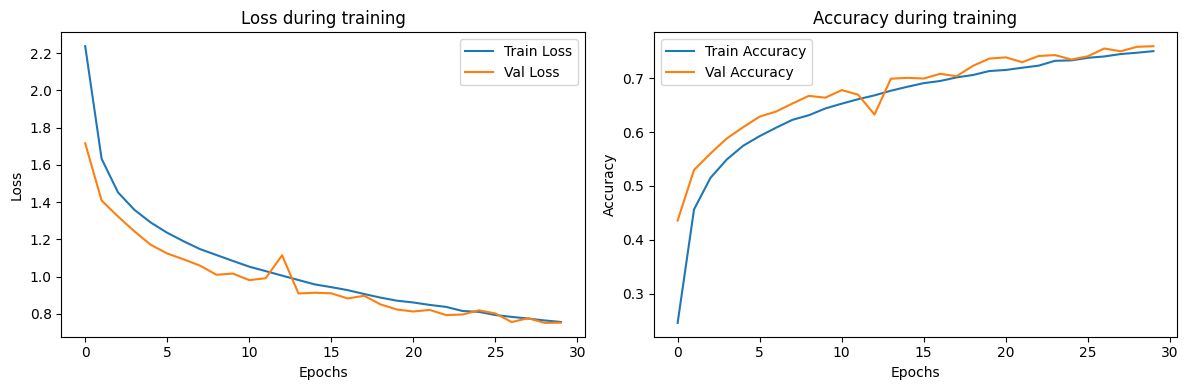

In [20]:
# Evaluation on the Test Set
print("\n--- Evaluation on the Test Set ---")
test_loss, test_accuracy = optimized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Visualization of the results
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss during training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy during training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Saving the Model

In [21]:
# Define the file name
final_model_path = os.path.join(models_dir, 'final_model_big.h5')
optimized_model.save(final_model_path)

print(f"Final model successfully saved in:\n{final_model_path}")

Final model successfully saved in:
./models/big/final_model_big.h5


## Quantization with QuantizeML

In [22]:
# Ensure the baseline_model has the best weights saved from the checkpoint
model_path_h5 = os.path.join(models_dir, 'final_model_big.h5')
optimized_model.load_weights(model_path_h5)
print(f"Float model weights loaded from: {model_path_h5}")

print("\n--- Evaluation on the Test Set ---")
test_loss, test_accuracy = optimized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Float model weights loaded from: ./models/big/final_model_big.h5

--- Evaluation on the Test Set ---
Test Loss: 0.7487
Test Accuracy: 75.39%


In [23]:

num_calibration_samples = 10240
indices = np.random.choice(len(X_train), num_calibration_samples, replace=False)
calibration_data = X_train[indices]

qparams = QuantizationParams(
    input_weight_bits=8,
    weight_bits=4,
    activation_bits=4,
)

with set_akida_version(AkidaVersion.v1):
    quantized_model = quantize(
        optimized_model,
        qparams=qparams,
        samples=calibration_data,
        epochs=10
    )

print("\n--- Quantized Model Structure ---")
quantized_model.summary()

quantized_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n--- Quantized Model Evaluation ---")
q_test_loss, q_test_accuracy = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Quantized): {q_test_loss:.4f}")
print(f"Test Accuracy (Quantized): {q_test_accuracy*100:.2f}%")

1024/1024 [==============================] - 3s 3ms/step

--- Quantized Model Structure ---
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 41, 9, 1)]        0         
                                                                 
 input_quantizer_5 (InputQu  (None, 41, 9, 1)          2         
 antizer)                                                        
                                                                 
 conv2d_20 (QuantizedConv2D  (None, 21, 5, 48)         480       
 )                                                               
                                                                 
 re_lu_31 (QuantizedReLU)    (None, 21, 5, 48)         96        
                                                                 
 conv2d_21 (QuantizedConv2D  (None, 11, 3, 96)         41568     
 )                          

### Fine Tuning Modello Quantizzato


In [24]:
print("\n--- Quantized Model Fine-Tuning (QAT) Alignment Strategy ---")

# Google Drive path
qat_model_path = os.path.join(checkpoints_dir, 'final_model_big_quantized.h5')
os.makedirs(os.path.dirname(qat_model_path), exist_ok=True)

BEST_LR = 0.000987758753644748
BEST_BATCH_SIZE = 64

qat_checkpoint = ModelCheckpoint(
    filepath=qat_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

qat_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Very low learning rate for post-quantization stability
quantized_model.compile(
    optimizer=Adam(learning_rate=BEST_LR),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Training
history_qat = quantized_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=BEST_BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[qat_checkpoint, qat_early_stopping, lr_scheduler],
    verbose=1
)

print(f"Fine-tuning completed and best weights saved directly to: {qat_model_path}")


--- Quantized Model Fine-Tuning (QAT) Alignment Strategy ---
Epoch 1/200
1830/1830 [==============================] - ETA: 0s - loss: 1.3740 - accuracy: 0.5539
Epoch 1: val_accuracy improved from -inf to 0.50859, saving model to ./models/big/checkpoint/final_model_big_quantized.h5
1830/1830 [==============================] - 63s 28ms/step - loss: 1.3740 - accuracy: 0.5539 - val_loss: 1.5429 - val_accuracy: 0.5086 - lr: 9.8776e-04
Epoch 2/200
1829/1830 [============================>.] - ETA: 0s - loss: 1.1924 - accuracy: 0.6027
Epoch 2: val_accuracy improved from 0.50859 to 0.60517, saving model to ./models/big/checkpoint/final_model_big_quantized.h5
1830/1830 [==============================] - 49s 27ms/step - loss: 1.1925 - accuracy: 0.6027 - val_loss: 1.1938 - val_accuracy: 0.6052 - lr: 9.8776e-04
Epoch 3/200
1830/1830 [==============================] - ETA: 0s - loss: 1.1493 - accuracy: 0.6180
Epoch 3: val_accuracy improved from 0.60517 to 0.61845, saving model to ./models/big/check

### Evaluation on test set

In [25]:
print("--- Quantized Model Evaluation ---")
quantized_model.load_weights(qat_model_path)
q_test_loss, q_test_accuracy = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Quantized): {q_test_loss:.4f}")
print(f"Test Accuracy (Quantized): {q_test_accuracy*100:.2f}%")

--- Quantized Model Evaluation ---
Test Loss (Quantized): 0.7876
Test Accuracy (Quantized): 75.04%


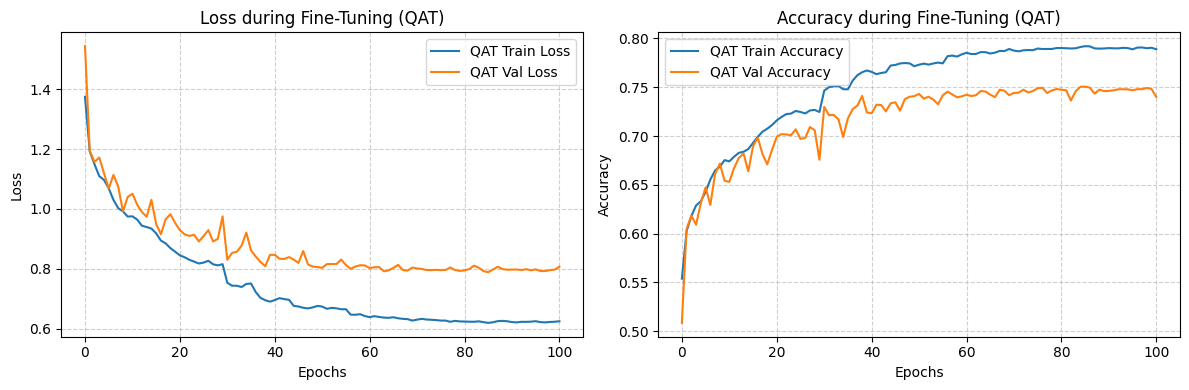

In [27]:
# Visualization of Fine-Tuning (QAT) results
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_qat.history['loss'], label='QAT Train Loss')
plt.plot(history_qat.history['val_loss'], label='QAT Val Loss')
plt.title('Loss during Fine-Tuning (QAT)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history_qat.history['accuracy'], label='QAT Train Accuracy')
plt.plot(history_qat.history['val_accuracy'], label='QAT Val Accuracy')
plt.title('Accuracy during Fine-Tuning (QAT)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Saving the Finetuned Quantized Model

In [28]:
# Save the fine-tuned quantized model weights
qat_model_path = os.path.join(models_dir, 'final_model_big_quantized.h5')
quantized_model.save_weights(qat_model_path)
print(f"Fine-tuned weights saved successfully to: {qat_model_path}")

Fine-tuned weights saved successfully to: ./models/big/final_model_big_quantized.h5


## Convertion to Akida SNN and Evaluation

In [29]:
# Load the best QAT weights into the quantized model
qat_model_path = os.path.join(models_dir, 'final_model_big_quantized.h5')
quantized_model.load_weights(qat_model_path)
print(f"QAT weights loaded from: {qat_model_path}")

# Verify that the weights are correct
_, acc_check = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Quantized accuracy with QAT weights (pre-conversion): {acc_check*100:.2f}%")

# Conversion
with set_akida_version(AkidaVersion.v1):
    akida_model = cnn2snn.convert(quantized_model)

print("Conversion completed.")

# Evaluation
preds = akida_model.predict(X_test)
akida_preds = np.argmax(preds, axis=-1).flatten()
akida_accuracy = np.mean(akida_preds == y_test)
print(f"\nAkida Accuracy: {akida_accuracy * 100:.2f}%")

# HW Mapping
device = akida.AKD1000()
akida_model.map(device=device)
akida_model.summary()

QAT weights loaded from: ./models/big/final_model_big_quantized.h5
Quantized accuracy with QAT weights (pre-conversion): 75.04%
Conversion completed.

Akida Accuracy: 75.05%
                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[41, 9, 1]   [1, 1, 18]    2          7       68   0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
HRC               1    
_________________________
CNP1              66   
_________________________
FNP3              2    
_________________________

___________________________________________________________________________
Layer (type)                   Output shape  Kernel shape      Components

===================== SW/input_quanti

### Saving the Finetuned Quantized Model

In [30]:
akida_fb_path = os.path.join(models_dir, 'final_model_big_quantized_akida.fb')
akida_model.save(akida_fb_path)

print(f"Akida SNN model saved successfully in .fb format: {akida_fb_path}")

Akida SNN model saved successfully in .fb format: ./models/big/final_model_big_quantized_akida.fb
